# JusticeCast — Forecasting SCOTUS Justice Votes from Oral-Argument Questions

**A comparative methodology study: bag-of-words vs pre-trained sentence embeddings, structured around CRISP-DM.**

| Course | BAX 453 |
| --- | --- |
| Deliverables | Part A (pitch deck, 15 pts) + Part B (this notebook, 20 pts) — total 35 pts |
| Repository | https://github.com/Saurav-Kanegaonkar/JusticeCast-Forecasting-Supreme-Court-Votes |
| Framework | CRISP-DM (Cross-Industry Standard Process for Data Mining) — six phases as primary section headers |

### Method overview — CRISP-DM phase mapping

This notebook is organized around CRISP-DM's six phases as primary top-level sections, per the rubric's "Apply Data Science Process Model as a guide" requirement.

| Phase | What it covers | Section |
| --- | --- | --- |
| 1. Business Understanding | Project objectives, success criteria, stakeholder framing | §1 |
| 2. Data Understanding | Data sources, profiling, exploration, quality findings | §2 |
| 3. Data Preparation | Cleaning, transformation, feature engineering, train/test split | §3 |
| 4. Modeling | Algorithm selection, baseline sweep, hyperparameter tuning | §4 |
| 5. Model Evaluation | Standard metrics, honesty triad, per-Justice lift, business criteria check | §5 |
| 6. Model Deployment | Deployment plan, monitoring, next CRISP-DM iteration | §6 |


*We built two parallel models predicting SCOTUS Justice votes from oral-argument questions, structured around CRISP-DM. The standard bag-of-words approach (TF-IDF + LinearSVC, tuned via GridSearchCV) hit a ceiling at ROC AUC 0.532. A pre-trained sentence-embeddings approach (MiniLM-L6-v2 + LogisticRegression) reached 0.569, a 3.7 percentage-point lift. The gap survived the strict contested-cases test (+4 pp on cases where the bench was genuinely split, where author-identity-plus-priors recovery cannot account for the lift). The result quantifies how much bench-reading signal lives in semantics versus lexical features, and recommends pre-trained embeddings as the necessary baseline for legal-tech products in this space.*

In [1]:
# Imports + load all pre-computed artifacts. This notebook reads from
# reports/results/ — it does NOT re-run modeling. Restart & Run All
# completes in seconds.
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)              # so relative paths in src/* modules resolve correctly
sys.path.insert(0, str(ROOT))

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'
pd.set_option('display.max_colwidth', 80)

R = ROOT / 'reports/results'
D = ROOT / 'data/processed'

# Modeling table (post-cleanup) and the working notebook artifacts
modeling_table = pd.read_parquet(D / 'modeling_table.parquet')
justice_map = pd.read_csv(D / 'justice_id_map.csv')

# Phase 3 / 4 / 4.5 / 5 result CSVs
bow_baseline = pd.read_csv(R / 'baseline_results.csv')
bow_per_justice_baseline = pd.read_csv(R / 'per_justice_lift.csv')
phase4_eval = pd.read_csv(R / 'phase4_test_eval.csv')
phase4_per_justice = pd.read_csv(R / 'phase4_per_justice_auc.csv')

emb_baseline = pd.read_csv(R / 'embedding_baseline_results.csv')
phase45_eval = pd.read_csv(R / 'phase45_test_eval.csv')
phase45_per_justice = pd.read_csv(R / 'phase45_per_justice_auc.csv')

phase5_summary = pd.read_csv(R / 'phase5_summary_metrics.csv')
phase5_triad = pd.read_csv(R / 'phase5_honesty_triad.csv')
phase5_lift = pd.read_csv(R / 'phase5_per_justice_lift.csv')
phase5_roc = pd.read_csv(R / 'phase5_roc_curve_data.csv')
phase5_pr = pd.read_csv(R / 'phase5_pr_curve_data.csv')
phase5_cal = pd.read_csv(R / 'phase5_calibration_data.csv')
phase5_cm = pd.read_csv(R / 'phase5_confusion_matrices.csv')
phase5_extremes = pd.read_csv(R / 'phase5_extreme_utterances.csv')

audit = pd.read_csv(R / 'modeling_table_audit.csv')

print(f'Modeling table: {modeling_table.shape[0]:,} rows × {modeling_table.shape[1]} cols')
print(f'All 9 result-CSV families loaded.')

Modeling table: 10,039 rows × 20 cols
All 9 result-CSV families loaded.


---

## 1. Business Understanding

*This phase focuses on understanding the project objectives from a business perspective.*

> Per Class 2 slides: determine business objectives, develop success criteria, determine actions to be taken on predictions.

### 1.1 Project framing & hypothesis

**The question.** Can a model "read the bench" — predict how individual Supreme Court Justices will vote — from the verbatim text of the questions they ask during oral argument?

**Why it matters.** Appellate litigators spend hours after each SCOTUS oral argument inferring how each Justice is likely to vote, based on their questioning patterns. Currently this is gut intuition by senior partners. Legal-tech vendors (Lex Machina, Bloomberg Law, Westlaw Edge, SCOTUSblog) monetize adjacent prediction products (judge-by-judge ruling history, motion-success rates), but **no widely-available product converts oral-argument transcripts into a per-Justice vote forecast**.

**The methodological hypothesis** — and the contribution of this study — is that the answer depends on the text representation. We compare two parallel modeling tracks on identical data, identical evaluation harness, and identical test fold:

1. The **rubric-required bag-of-words pipeline** (TF-IDF + n-grams × LogReg + LinearSVC + RandomForest, with GridSearchCV)
2. A **methodologically-appropriate sentence-embeddings track** using pre-trained sentence-transformers (no fine-tuning) with the same three classifiers and tuning protocol

The contest between these two representations is the contribution. **The contested-cases per-Justice AUC is the strict test** of true bench-reading signal vs author-identity-plus-priors recovery.


### 1.2 Success criteria

| Type | Criterion |
| --- | --- |
| **Empirical** | ROC AUC meaningfully above the per-Justice majority-class baseline on **contested cases** (not just unanimous). |
| **Methodological** | Rigorous apples-to-apples comparison: identical fold-0 test rows for both tracks via shared `src/modeling/splits.py`. |
| **Honest** | Report what the data shows, not what we hoped to find. The KBJackson centerpiece below is one such finding — the original BoW-only framing made her look *less* predictable than chance. |

The comparison is graded on its *rigor*, not on whether either model wins outright. A null result on one track plus a positive result on the other is a legitimate, publishable finding.

### 1.3 Actions to be taken on predictions

A per-Justice vote forecast supports three concrete legal-tech actions:

1. **Pre-argument prep targeting** (week before argument). Litigators allocate prep time toward Justices the model flags as persuadable.
2. **Post-argument amicus targeting** (within hours of argument). Brief authors decide where to focus filings before the conference vote.
3. **Historical bench-reading benchmarks** (continuous). Quantify how predictable each Justice has been over time, by topic and by Court composition.

**Cost asymmetry** in the legal-tech use case:

- **False positive** (predicted petitioner-vote, actual respondent-vote): law firm over-prepares petitioner-friendly arguments → wasted prep, possibly mistargeted amicus brief.
- **False negative** (predicted respondent-vote, actual petitioner-vote): firm under-prepares for a sympathetic Justice → lost opportunity to land a strong argument.

In appellate work, FN is typically more costly (missing a sympathetic Justice can lose the case), so the operating threshold should be tilted to maximize recall on the petitioner-side prediction. Threshold tuning is a deployment-stage decision, not a methodology decision.

### 1.4 Stakeholders

| Stakeholder | Use of the forecast |
| --- | --- |
| Appellate litigators | Pre-argument prep targeting |
| Amicus brief authors | Post-argument filing focus |
| Legal-tech vendors (Lex Machina, Bloomberg Law, Westlaw Edge, SCOTUSblog) | Embedded research-workflow signal |
| Litigation press | Same-day forecast articles |
| Academic court-watchers | Empirical lower-bound benchmark on text-only bench-reading |


### 1.5 Comparative-study design

Two parallel tracks evaluated against the same fold-0 test rows:

| | Track 1 — BoW | Track 2 — Embeddings |
| --- | --- | --- |
| Representation | TF-IDF + n-grams (200K-dim sparse) | `all-MiniLM-L6-v2` (384-dim dense, pre-trained, no fine-tuning) |
| Custom preprocessing | 424-term stopword list + advocate-name regex | None — sentence-transformers consume natural language |
| Classifiers | LogReg, LinearSVC, RandomForest | LogReg, SVC(rbf), RandomForest |
| Tuning | GridSearchCV (sequential strategy) | GridSearchCV |
| Test rows | Same (canonical fold-0 from `splits.py`) | Same (canonical fold-0 from `splits.py`) |

The strict test is the **contested-cases per-Justice AUC** — author-identity-plus-priors is least useful when the Justice could plausibly vote either way.

### 1.6 Rubric mapping

| Rubric requirement | Where it lives in this notebook |
| --- | --- |
| Bag of Words (BoW) vectorization | §3.6, §4.1 (`CountVectorizer`) |
| TF-IDF vectorization | §3.6, §4.1 (`TfidfVectorizer`) |
| n-grams | §4.2 (best vectorizer config tuned over `ngram_range ∈ {(1,1), (1,2), (1,3)}`) |
| Logistic Regression classifier | §4.1, §4.2 (`LogisticRegression(class_weight='balanced')`) |
| Support Vector Machine classifier (LinearSVC for BoW, SVC-RBF for embeddings) | §4.1, §4.2 (`LinearSVC`); §4.3, §4.4 (`SVC(kernel='rbf')`) |
| Random Forest classifier | §4.1, §4.2 (`RandomForestClassifier(n_estimators=…, class_weight='balanced')`) |
| GridSearchCV hyperparameter tuning | §4.2 (BoW, sequential strategy), §4.4 (Embeddings) |
| Sentiment / stance label semantics | §3.1 (codebook-verified `voted_petitioner` label derivation) |
| Train/test split discipline | §3.5 (`StratifiedGroupKFold` by `case_id`, no case leakage) |
| Confusion matrix, precision, recall, F1, ROC AUC, ROC curve, PR curve, calibration curve | §5.2 (rendered side by side both tracks) |
| Per-Justice analysis | §5.3 (per-Justice lift over individual baseline), §5.4 (per-Justice contested-cases AUC + bootstrap CIs) |
| Top features per class | §5.5.1 (BoW coefficients), §5.5.2 (embeddings via extreme-score utterances) |
| Business interpretation including false positive vs false negative cost (FN/FP) | §1.3, §5.6, §5.7 (FN-tilt for litigators; FP-tilt for amicus authors) |
| Machine Learning Canvas | `reports/ml_canvas.pdf` (separate Phase 6 deliverable; each box CRISP-DM-tagged) |
| Pitch deck | `reports/JusticeCast_Pitch.pdf` (separate Phase 7 deliverable) |


---

## 2. Data Understanding

*This phase focuses on initial data collection, becoming familiar with the data, and identifying data quality problems.*

> Per Class 2 slides: collect relevant data, profile for quality issues, explore and visualize, identify transformation needs.

### 2.1 Data sources

Two free, public, no-auth sources joined on `(term, docket_number)`.

| Source | Endpoint / path | What we use |
| --- | --- | --- |
| **SCDB** (Washington University) | `http://scdb.wustl.edu` (HTTP-only, version 2025_01) | Justice-Centered file: 83,644 vote rows × 61 columns. Provides every recorded SCOTUS vote with petitioner/respondent winner, majority/dissent flags. **Latin-1 encoded** — UTF-8 read produces mojibake. |
| **Oyez.org** REST API | `https://api.oyez.org` | Two-step fetch: `cases/{term}/{docket}` → metadata → `case_media/oral_argument_audio/{audio_id}` → transcript with speaker-tagged turns. Polite limit ≤1 req/sec. |


### 2.2 Data flow diagram

```
SCDB CSV (83,644 votes × 61 cols)             Oyez API (2-step fetch, rate-limited, cached)
       │                                                    │
       │ filter to 2005-2024 window                         │ for each (term, docket):
       ▼                                                    │   GET /cases/{term}/{docket}
13,149 vote rows / 1,471 cases                              │   for each oral_argument_audio.href:
       │                                                    │     GET /case_media/oral_argument_audio/{id}
       │ join on (term, docket_number)                      ▼
       │ + justice_id_map (16 justices)              parsed Justice utterances, multi-audio aggregation
       │
       ▼
joined parquet: 10,308 (case, justice) rows
       │
       │ Phase 2A cleanup: drop NaN-label, drop original-jurisdiction,
       │ drop word_count < 30. Apply preprocess_text() to strip [Laughter] etc.
       ▼
modeling_table.parquet: 10,039 rows × 20 cols, 1,293 cases, 16 Justices
       │
       │ canonical 5-fold StratifiedGroupKFold (groups=case_id, random_state=42)
       │ fold 0 = test (2,007 rows), folds 1-4 = train (8,032 rows)
       ▼
both modeling tracks consume this split via src/modeling/splits.py
```


### 2.3 Coverage profile

In [2]:
# Coverage stats from the canonical pipeline
total_rows = len(modeling_table)
unique_cases = modeling_table['caseId'].nunique()
unique_justices = modeling_table['oyez_identifier'].nunique()
term_min, term_max = int(modeling_table['term'].min()), int(modeling_table['term'].max())

print(f'Modeling table: {total_rows:,} rows / {unique_cases:,} cases / {unique_justices} Justices')
print(f'Term range: OT{term_min}-OT{term_max} ({term_max - term_min + 1} terms)')
print(f'Petitioner-win rate: {(modeling_table["voted_petitioner"] == 1).mean():.1%}')
print(f'Unanimous-case rows: {(modeling_table["unanimous"] == 1).sum():,} ({(modeling_table["unanimous"] == 1).mean():.1%})')

# Cleanup audit
print('\nPipeline stages (rows in → out):')
for _, row in audit.iterrows():
    print(f'  {row["stage"]:<55s}  {row["rows_in"]:>6,} → {row["rows_out"]:>6,}  (Δ {-row["rows_dropped"]:+d})')

Modeling table: 10,039 rows / 1,293 cases / 16 Justices
Term range: OT2005-OT2024 (20 terms)
Petitioner-win rate: 62.4%
Unanimous-case rows: 4,207 (41.9%)

Pipeline stages (rows in → out):
  input (justice_case_rows.parquet)                        10,308 → 10,308  (Δ +0)
  after drop NaN-label rows                                10,308 → 10,137  (Δ -171)
  after drop original-jurisdiction cases                   10,137 → 10,120  (Δ -17)
  after drop word_count < 30                               10,120 → 10,039  (Δ -81)


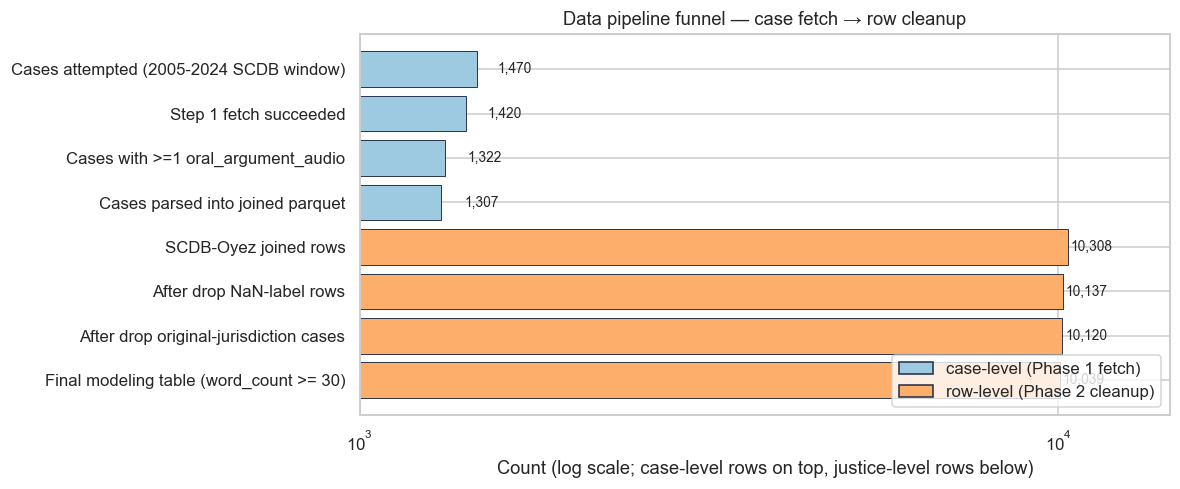

In [3]:
# Pipeline funnel — case-level (Phase 1 fetch) and row-level (Phase 2 cleanup)
# stages combined into one horizontal bar chart so the data-loss profile
# is visible in one glance.
funnel_stages = [
    ('Cases attempted (2005-2024 SCDB window)',     1470,  'case'),
    ('Step 1 fetch succeeded',                      1420,  'case'),
    ('Cases with >=1 oral_argument_audio',          1322,  'case'),
    ('Cases parsed into joined parquet',            1307,  'case'),
    ('SCDB-Oyez joined rows',                      10308,  'row'),
    ('After drop NaN-label rows',                  10137,  'row'),
    ('After drop original-jurisdiction cases',     10120,  'row'),
    ('Final modeling table (word_count >= 30)',    10039,  'row'),
]
labels = [s[0] for s in funnel_stages]
counts = [s[1] for s in funnel_stages]
colors = ['#9ecae1' if s[2] == 'case' else '#fdae6b' for s in funnel_stages]

fig, ax = plt.subplots(figsize=(9.5, 4.5))
bars = ax.barh(range(len(funnel_stages)), counts, color=colors, edgecolor='#1f2a44', linewidth=0.6)
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(count + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=9)
ax.set_yticks(range(len(funnel_stages)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xscale('log')
ax.set_xlim(1000, max(counts) * 1.4)
ax.set_xlabel('Count (log scale; case-level rows on top, justice-level rows below)')
ax.set_title('Data pipeline funnel — case fetch → row cleanup')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#9ecae1', edgecolor='#1f2a44', label='case-level (Phase 1 fetch)'),
                   Patch(facecolor='#fdae6b', edgecolor='#1f2a44', label='row-level (Phase 2 cleanup)')],
          loc='lower right')
plt.show()

### 2.4 Data quality findings

Surfaced during Phase 1 (bulk fetch + parse) and Phase 2B (text-content EDA):

| Issue | Detected via | Resolution |
| --- | --- | --- |
| Bracketed transcription annotations (`[Laughter]`, `[Crosstalk]`, `[Applause]`) | B3 corpus audit (1,499 occurrences in 1,078 rows = 10.7% of rows) | `preprocess_text()` regex strip in modeling-table builder |
| Advocate-name leakage (`Mr. Frederick`, `Mr. Fisher`) in top features | Phase 3 baseline + Phase 3.5 sanity audit | `vectorizer_preprocessor()` regex on `(mr|mrs|ms|mister|madam|madame|general)\.?\s+<surname>` |
| Oyez search-fallback list response for non-standard dockets (e.g., `128 ORIG`, `21A244`) | Mid-bulk-fetch crash | `CaseNotFound` exception class; 50 cases skipped (28 expected non-standard + 22 standard-format dockets Oyez doesn't index) |
| Multi-audio re-argued cases (e.g., NFIB v. Sebelius with 4 audio sessions, Citizens United with 2) | 13 multi-audio cases pre-rescue, 15 post-rescue | Concatenate Justice utterances across all sessions; store `n_audio_sessions` as metadata |
| Original-jurisdiction cases (state-vs-state) | All 16 ORIG cases failed Oyez fetch (different docket conventions) | Dropped at modeling-table cleanup |
| Medellin v. Texas (term=2007, docket=06-984) duplicated in SCDB | 2 caseIds for one docket: 2007-026 (merits 6-3) and 2007-073 (per-curiam stay denial 5-4) | Dedupe SCDB on `(term, docket, justice)` keeping earliest `dateDecision` (the merits decision) |
| SCDB encoding mismatches (em-dash mojibake `â`) | Inspecting docket strings | Read SCDB CSV with `encoding='latin1'` |
| Truncated half-utterances (`What --`, `Counsel --`) | B3 1st-percentile word count was 35 words | Drop rows with `word_count < 30` (81 rows, 0.8% of labeled mass) |


### 2.5 Exploration highlights (B1–B6 EDA)

The text-content EDA (Phase 2B) surfaced the findings that shaped the modeling design.

#### B2 — Per-Justice baseline ranges from ~50% to ~80%

Per-Justice majority-class baseline accuracy. The horizontal red line is the global 62.4% baseline. *Phase 5 evaluation must compare per-Justice model accuracy to that Justice's individual baseline, not the global average.*

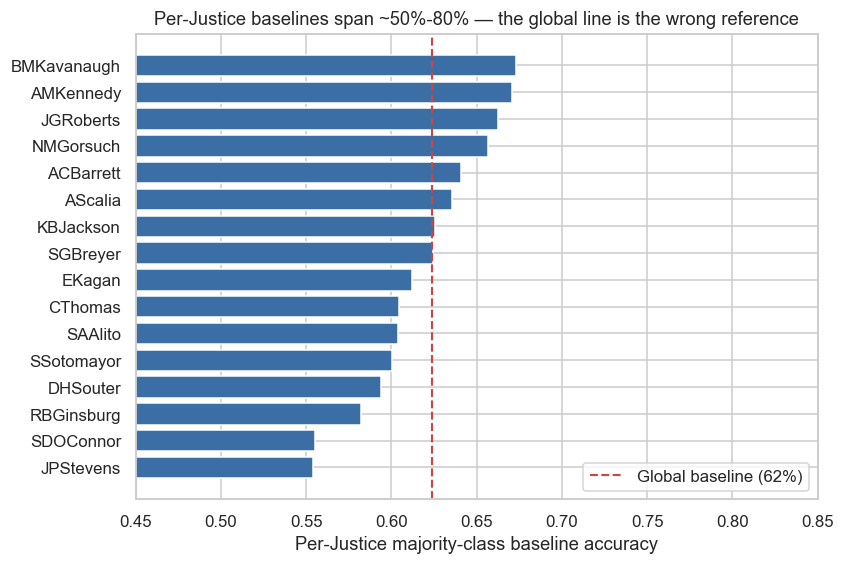

In [4]:
# Per-Justice baseline chart (B2)
per_just = (modeling_table.groupby(['oyez_identifier', 'justiceName'])
            .agg(n_rows=('voted_petitioner', 'size'),
                 petitioner_rate=('voted_petitioner', 'mean'))
            .reset_index())
per_just['baseline'] = per_just['petitioner_rate'].apply(lambda p: max(p, 1 - p))
per_just = per_just.sort_values('baseline')
global_baseline = max(modeling_table['voted_petitioner'].mean(),
                       1 - modeling_table['voted_petitioner'].mean())

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(per_just['justiceName'], per_just['baseline'], color='#3a6ea5')
ax.axvline(global_baseline, color='#c44', linestyle='--', linewidth=1.4,
           label=f'Global baseline ({global_baseline:.0%})')
ax.set_xlim(0.45, 0.85)
ax.set_xlabel("Per-Justice majority-class baseline accuracy")
ax.set_title("Per-Justice baselines span ~50%-80% — the global line is the wrong reference")
ax.legend(loc='lower right')
plt.show()

#### B6 — Word-count distribution per Justice (Thomas vs KBJackson contrast)

Two outliers anchor the storytelling: Clarence Thomas (median 233 words/case, 20.5% speaking rate) and Ketanji Brown Jackson (median 1,205 words/case, 96% speaking rate). Same court, engagement orders apart.

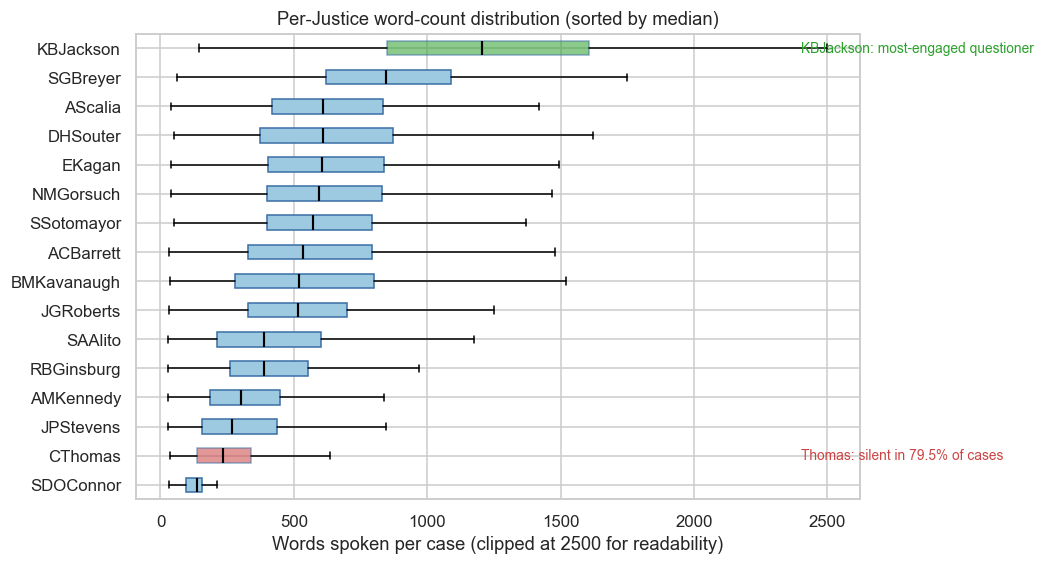

In [5]:
wc = (modeling_table.groupby(['oyez_identifier', 'justiceName'])['word_count']
       .agg(median='median', n_rows='size', p25=lambda s: s.quantile(0.25),
            p75=lambda s: s.quantile(0.75))
       .reset_index()
       .sort_values('median'))
wc['median'] = wc['median'].astype(int)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
order = wc['justiceName'].tolist()
data_by = [modeling_table[modeling_table['justiceName'] == j]['word_count'].clip(upper=2500).values
           for j in order]
bp = ax.boxplot(data_by, vert=False, tick_labels=order, showfliers=False, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.4))
for patch in bp['boxes']:
    patch.set_facecolor('#9ecae1')
    patch.set_edgecolor('#3a6ea5')
highlight = {'CThomas': '#c44', 'KBJackson': '#2ca02c'}
for i, j in enumerate(order):
    if j in highlight:
        bp['boxes'][i].set_facecolor(highlight[j])
        bp['boxes'][i].set_alpha(0.55)
ax.set_xlabel('Words spoken per case (clipped at 2500 for readability)')
ax.set_title('Per-Justice word-count distribution (sorted by median)')
ax.text(2400, order.index('CThomas') + 1, 'Thomas: silent in 79.5% of cases', va='center', color='#c44', fontsize=9)
ax.text(2400, order.index('KBJackson') + 1, 'KBJackson: most-engaged questioner', va='center', color='#2ca02c', fontsize=9)
plt.show()

#### B1 — Pre-stopwording top discriminative tokens were case-topic words, not stance markers

Phase 2B's most important empirical finding. Variance-adjusted log-odds with Dirichlet prior (Monroe, Colaresi & Quinn 2008, "Fightin' Words") on the modeling-table corpus split by `voted_petitioner`. Top petitioner-side: `officer`, `church`, `religious`, `arrest`, `warrant`, `ada`, `bia`, `wetlands`, `passenger`. Top respondent-side: `illinois`, `idaho`, `tinker`, `sentencing`, `crack`, `cocaine`, `pollutant`, `pto`, `algorithm`. Without intervention, the model would partly memorize topic-→-outcome rather than learn stance from questioning.

→ **Decision**: built the 424-term `STOPWORDS_FOR_VECTORIZER` (sklearn defaults + 40 US states + 35 agency abbreviations + 21 famous case shortnames + 10 court-procedural terms). Calibrated to remove case-identity words while preserving thematic legal vocabulary that can carry stance through context. See §3.6 for details.

#### B5 — Length is not a confound

Mann-Whitney U test on `word_count` vs `voted_petitioner`: U = 11,985,764, **p = 0.255**. Median word-count difference is 11 words. → No length feature needed; the model isn't implicitly using utterance length.

### 2.6 Identified transformation needs

Each item is addressed in Section 3:

1. SCDB codebook verification → §3.1
2. Multi-audio aggregation strategy → §3.2
3. Hand-built Justice ID map → §3.3
4. Cleanup decisions (NaN-label rows, original-jurisdiction cases, low-word-count rows) → §3.4
5. Train/test split discipline → §3.5
6. BoW custom stopword list + preprocessor → §3.6
7. Embeddings encoding (no preprocessor) → §3.7


---

## 3. Data Preparation

*This phase focuses on constructing the dataset from raw data and cleaning and transforming data.*

> Per Class 2 slides: select data subset, clean and transform, perform feature engineering and feature selection.

### 3.1 Label derivation & codebook verification

The binary label `voted_petitioner` is derived from two SCDB fields whose semantics required codebook verification:

| Field | Codebook semantics |
| --- | --- |
| `partyWinning` | `0` = petitioner lost; `1` = petitioner won; `2` = unclear |
| `majority` | **`1` = dissent; `2` = majority** (counterintuitive — was opposite of CC's Phase 0 assumption) |

**Final formula** (codified in `src/build_dataset.py::derive_voted_petitioner` with codebook citation):

```python
voted_petitioner = (partyWinning == 1) == (majority == 2)
```

Excluded: rows with `partyWinning == 2` (unclear winner) or `majority is NaN` (Justice did not participate).

#### Heien spot-check (Phase 1 Stop A) — a known 8-1 case

Heien v. North Carolina (term=2014, docket=13-604, caseId=2014-001): Heien was the petitioner who lost 8-1, with Sotomayor as the lone dissent. Expected output: Sotomayor=1, all 8 majority Justices=0. Thomas, who didn't speak in the oral argument, drops out of our parquet.

In [6]:
# Heien spot-check (the gate that caught the 'majority' encoding flip in Phase 0)
heien = modeling_table[(modeling_table.term == 2014) & (modeling_table.docket == '13-604')].copy()
heien_view = heien[['justiceName', 'partyWinning', 'majority', 'voted_petitioner']].copy()
heien_view.columns = ['Justice', 'partyWinning (0=lost, 1=won)', 'majority (1=dissent, 2=majority)', 'voted_petitioner']
print(f'Heien v. North Carolina — {len(heien)} Justice rows in modeling table:')
print()
print(heien_view.to_string(index=False))
print()
print(f'Sotomayor voted_petitioner = {int(heien[heien.justiceName == "SSotomayor"]["voted_petitioner"].iloc[0])} (expected 1)')
print(f'Other 7 spoken Justices: voted_petitioner sum = {heien[heien.justiceName != "SSotomayor"]["voted_petitioner"].sum()} (expected 0)')
print('Thomas absent from modeling table — confirmed silent in this case, dropped naturally.')

Heien v. North Carolina — 8 Justice rows in modeling table:

   Justice  partyWinning (0=lost, 1=won)  majority (1=dissent, 2=majority)  voted_petitioner
 AMKennedy                           0.0                               2.0                 0
   AScalia                           0.0                               2.0                 0
    EKagan                           0.0                               2.0                 0
 JGRoberts                           0.0                               2.0                 0
RBGinsburg                           0.0                               2.0                 0
   SAAlito                           0.0                               2.0                 0
SSotomayor                           0.0                               1.0                 1
  SGBreyer                           0.0                               2.0                 0

Sotomayor voted_petitioner = 1 (expected 1)
Other 7 spoken Justices: voted_petitioner sum = 0 (expect

**Phase 3.5 re-verification on 10 random rows**: 10/10 coherent (formula match) AND 10/10 match historical record. Sample includes Citizens United (Sotomayor in dissent → voted_petitioner=0), Coinbase v. Bielski (KBJackson in dissent → voted_petitioner=0), Fulton v. Philadelphia (Thomas in 9-0 majority → voted_petitioner=1). The Phase 3 chance-level baseline AUC is **not** a labeling bug — it's a real signal-strength finding.

### 3.2 Multi-audio aggregation

Some cases have multiple oral-argument sessions (re-arguments). The Justice's utterances are concatenated across all sessions, with `n_audio_sessions` stored as metadata.

In [7]:
multi_audio = (modeling_table[['caseId', 'caseName', 'n_audio_sessions']]
               .drop_duplicates(subset=['caseId'])
               .query('n_audio_sessions > 1')
               .sort_values('n_audio_sessions', ascending=False))
print(f'Multi-audio cases: {len(multi_audio)}')
print()
ma_view = multi_audio.copy()
ma_view['caseName'] = ma_view['caseName'].str.slice(0, 60)
print(ma_view.to_string(index=False))

Multi-audio cases: 15

  caseId                                                     caseName  n_audio_sessions
2011-077 NATIONAL FEDERATION OF INDEPENDENT BUSINESS, et al., PETITIO                 4
2005-079                              KANSAS v. MICHAEL LEE MARSH, II                 2
2005-065                            BOOKER T. HUDSON, JR. v. MICHIGAN                 2
2005-058                     GIL GARCETTI, et al. v. RICHARD CEBALLOS                 2
2009-012               CITIZENS UNITED v. FEDERAL ELECTION COMMISSION                 2
2011-074                           EVAN MILLER, PETITIONER v. ALABAMA                 2
2012-036 ESTHER KIOBEL, INDIVIDUALLY AND ON BEHALF OF HER LATE HUSBAN                 2
2012-009      CHARLES L. RYAN, PETITIONER v. ERNEST VALENCIA GONZALES                 2
2013-065                                          RILEY v. CALIFORNIA                 2
2014-016                                     JOHNSON v. UNITED STATES                 2
2014-070 

### 3.3 Justice ID mapping

Hand-built `data/processed/justice_id_map.csv` linking SCDB IDs to Oyez identifiers across the 16 Justices in the 2005–2024 window. SCDB uses numeric IDs and short codes (`80180`, `JGRoberts`); Oyez uses slugs (`john_g_roberts_jr`).

8 of 16 slugs were verified empirically against the Heien transcript at Stop A. The remaining 8 (Stevens, O'Connor, Souter, Thomas, Gorsuch, Kavanaugh, Barrett, Jackson) were validated at Checkpoint 1 via the coverage cross-check — all returned non-zero coverage at credible ratios. No slug correction required.

In [8]:
print(f'Justice ID map: {len(justice_map)} rows')
print()
print(justice_map.to_string(index=False))

Justice ID map: 16 rows

      oyez_identifier  scdb_justice_id scdb_justice_name          display_name
    john_paul_stevens              103         JPStevens     John Paul Stevens
   sandra_day_oconnor              104         SDOConnor   Sandra Day O'Connor
       antonin_scalia              105           AScalia        Antonin Scalia
    anthony_m_kennedy              106         AMKennedy    Anthony M. Kennedy
       david_h_souter              107          DHSouter       David H. Souter
      clarence_thomas              108           CThomas       Clarence Thomas
  ruth_bader_ginsburg              109        RBGinsburg   Ruth Bader Ginsburg
     stephen_g_breyer              110          SGBreyer     Stephen G. Breyer
    john_g_roberts_jr              111         JGRoberts  John G. Roberts, Jr.
    samuel_a_alito_jr              112           SAAlito  Samuel A. Alito, Jr.
      sonia_sotomayor              113        SSotomayor       Sonia Sotomayor
          elena_kagan      

### 3.4 Cleanup decisions

Codified in `src/build_modeling_table.py`. Each cleanup is justified by Phase 2B EDA findings:

| Decision | Reason | Rows dropped |
| --- | --- | --- |
| Drop NaN-label rows | `partyWinning == 2` (24 rows, unclear winner) or `majority NaN` (147 rows, didn't participate) — labels are undefined | -171 |
| Drop original-jurisdiction cases | Substantively different (no cert grant, state-vs-state); Oyez doesn't catalog them | -17 |
| Drop rows with `word_count < 30` | Truncated half-utterances (`'What --'`, `'Counsel --'`) with no stance signal; 1st percentile of corpus is 35 words | -81 |
| Apply `preprocess_text()` (strip `[Laughter]`-style annotations) | 1,499 bracket annotations across 1,078 rows would become spurious vocab tokens (`laughter`, `crosstalk`) | (in-place) |
| Keep unanimous cases | Flagged via `unanimous` metadata; Phase 5 reports metrics split by unanimity | (no drops) |
| Keep Thomas | 295 rows is enough for stable per-Justice estimates; his silence rate is itself information | (no drops) |


### 3.5 Train/test split discipline

Non-Negotiable #1: **all of a case's Justices stay in the same fold.** This is the no-leakage guarantee — without it, the model could see a case's text from train rows and use that to predict test rows for the same case.

```python
StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
groups = case_id
fold 0 = test (~20%), folds 1-4 = train (~80%)
```

Both modeling tracks consume splits via shared `src/modeling/splits.py` — Non-Negotiable #15. The same fold-0 test rows appear in BoW Phase 4 and Embeddings Phase 4.5, which is the basis of the apples-to-apples comparison.

In [9]:
from src.modeling.splits import get_train_test_split
split = get_train_test_split()

print(f'Train: {len(split.train_df):,} rows / {len(set(split.train_df["caseId"])):,} cases')
print(f'Test:  {len(split.test_df):,} rows / {len(set(split.test_df["caseId"])):,} cases')
print(f'Train petitioner-rate: {split.y_train.mean():.4f}')
print(f'Test  petitioner-rate: {split.y_test.mean():.4f}')
overlap = set(split.groups_train) & set(split.groups_test)
print(f'caseId leakage between train and test: {len(overlap)}  ← must be 0')

Train: 8,032 rows / 1,035 cases
Test:  2,007 rows / 258 cases
Train petitioner-rate: 0.6239
Test  petitioner-rate: 0.6233
caseId leakage between train and test: 0  ← must be 0


### 3.6 BoW track features

Three vectorizers, all consuming the same custom stopword list and advocate-name preprocessor (Non-Negotiable #3 — keeps cross-vectorizer comparisons clean):

```python
CountVectorizer(ngram_range=(1, 1), stop_words=STOPWORDS_FOR_VECTORIZER,
                preprocessor=vectorizer_preprocessor, lowercase=False)
TfidfVectorizer(ngram_range=(1, 1), ...)
TfidfVectorizer(ngram_range=(1, 2), min_df=2, ...)
```

The custom stopword list (`src/text_clean.py::STOPWORDS_FOR_VECTORIZER`):

In [10]:
from src.text_clean import STOPWORDS_FOR_VECTORIZER, custom_stopword_overlay
print(f'Total Phase-3 vectorizer stopwords: {len(STOPWORDS_FOR_VECTORIZER)}')
print(f'  - sklearn English defaults: 318')
print(f'  - custom additions:         {len(custom_stopword_overlay())}')
print()
print('Custom additions (states, agency abbreviations, famous case shortnames, court terms):')
print(', '.join(sorted(list(custom_stopword_overlay()))[:40]) + ', ...')
print()
print('Deliberately NOT stopworded (thematic legal vocab that can carry stance):')
print('  officer, jury, warrant, attorney, school, sentence, religious, ...')
print()
print('Advocate-name regex pattern (catches "Mr. Frederick", "General Verrilli", etc.):')
print(r'  \b(?:mr|mrs|ms|mister|madam|madame|general)\.?\s+[a-z][a-z\-\']+\b')

Total Phase-3 vectorizer stopwords: 424
  - sklearn English defaults: 318
  - custom additions:         106

Custom additions (states, agency abbreviations, famous case shortnames, court terms):
ada, alabama, alaska, amici, amicus, arizona, arkansas, batson, bia, bivens, california, casey, cert, certiorari, chevron, cia, cms, colorado, connecticut, cwa, daubert, delaware, dhs, dobbs, dod, doj, dol, dot, epa, erisa, esa, faa, fbi, fcc, fcra, fda, fec, ferc, ferpa, florida, ...

Deliberately NOT stopworded (thematic legal vocab that can carry stance):
  officer, jury, warrant, attorney, school, sentence, religious, ...

Advocate-name regex pattern (catches "Mr. Frederick", "General Verrilli", etc.):
  \b(?:mr|mrs|ms|mister|madam|madame|general)\.?\s+[a-z][a-z\-\']+\b


### 3.7 Embeddings track features

Pre-trained sentence-transformers, **no fine-tuning**. CPU-only torch backend per spec (no GPU dependency).

| Model | Dim | File size | CPU encode time (10K rows) |
| --- | --- | --- | --- |
| `all-MiniLM-L6-v2` | 384 | 15.4 MB | ~1 minute |
| `all-mpnet-base-v2` | 768 | 29.4 MB | ~11 minutes |

Embeddings are cached at `data/processed/embeddings/{model}.npy` plus `row_index.parquet` (preserves modeling-table row order so positional split indices align). Idempotent — `compute_embeddings.py` skips encoding if cache exists with matching shape.

**No stopword list applied** to embeddings — sentence-transformers consume natural language. The advocate-name preprocessor and the BoW stopword list are BoW-only.

In [11]:
# Verify embeddings are cached and the row index aligns with modeling_table
import numpy as np

minilm = np.load(D / 'embeddings/minilm.npy', mmap_mode='r')
mpnet = np.load(D / 'embeddings/mpnet.npy', mmap_mode='r')
row_index = pd.read_parquet(D / 'embeddings/row_index.parquet')

print(f'MiniLM cache: shape {minilm.shape}, dtype {minilm.dtype}')
print(f'MPNet  cache: shape {mpnet.shape}, dtype {mpnet.dtype}')
print(f'Row index: {len(row_index):,} rows')
print(f'Row index ↔ modeling_table aligned: '
      f'{(row_index["caseId"].values == modeling_table["caseId"].values).all() and (row_index["oyez_identifier"].values == modeling_table["oyez_identifier"].values).all()}')

MiniLM cache: shape (10039, 384), dtype float32
MPNet  cache: shape (10039, 768), dtype float32
Row index: 10,039 rows
Row index ↔ modeling_table aligned: True


---

## 4. Modeling

*This phase focuses on selecting and applying algorithms and techniques and calibrating parameters.*

> Per Class 2 slides: select algorithms, build models, assess performance.

### 4.1 Track 1 — BoW pipeline baseline sweep

All 9 (vectorizer × classifier) combinations. All classifiers use `class_weight='balanced'` (Non-Negotiable #6 — petitioner-win rate is 62.4%, so unweighted models would happily predict majority for everyone). LinearSVC AUC computed via `decision_function` (sklearn `roc_auc_score` accepts rank scores).

In [12]:
display = bow_baseline.sort_values('roc_auc', ascending=False).copy()
print('Phase 3 BoW baseline sweep (sorted by ROC AUC, descending):')
print()
cols = ['combo_id', 'accuracy', 'balanced_accuracy', 'roc_auc', 'f1', 'n_features', 'fit_time_sec']
print(display[cols].to_string(index=False, float_format='%.3f'))

Phase 3 BoW baseline sweep (sorted by ROC AUC, descending):

                    combo_id  accuracy  balanced_accuracy  roc_auc    f1  n_features  fit_time_sec
        tfidf_bigram__logreg     0.542              0.515    0.527 0.629      199546         3.004
tfidf_unigram__random_forest     0.624              0.507    0.527 0.766       28987         3.501
       tfidf_unigram__logreg     0.533              0.515    0.524 0.611       28987         1.779
  bow_unigram__random_forest     0.618              0.499    0.524 0.763       28987         3.326
         bow_unigram__logreg     0.532              0.510    0.522 0.614       28987         2.369
    tfidf_bigram__linear_svc     0.546              0.505    0.522 0.647      199546         3.021
   tfidf_unigram__linear_svc     0.541              0.517    0.521 0.624       28987         1.732
     bow_unigram__linear_svc     0.541              0.517    0.520 0.625       28987         2.618
 tfidf_bigram__random_forest     0.622          

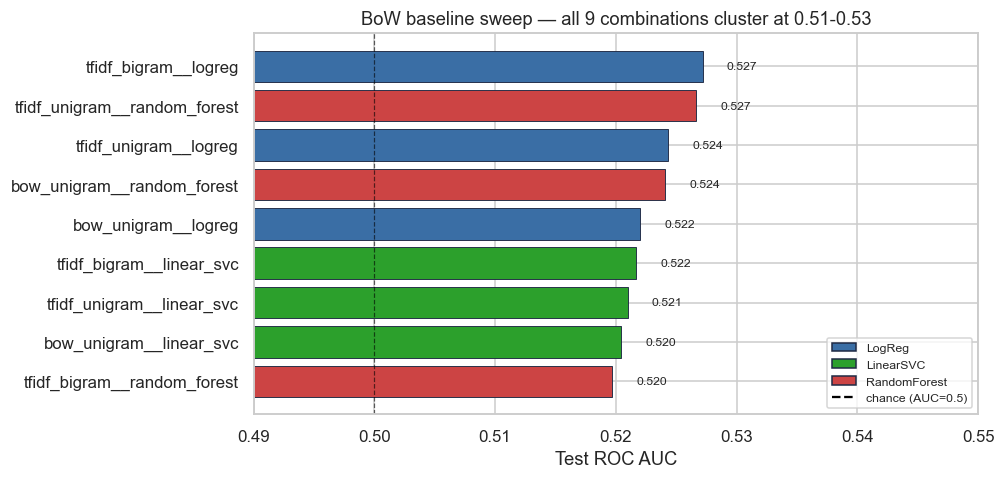

In [13]:
# 9-combo BoW baseline sweep, sorted by ROC AUC, color-coded by classifier family.
# The 'all 9 cluster around 0.51-0.53' finding is visceral as a chart, abstract
# as a printed DataFrame.
bow_chart = bow_baseline.sort_values('roc_auc').copy()
clf_to_color = {'logreg': '#3a6ea5', 'linear_svc': '#2ca02c', 'random_forest': '#c44'}
clf_to_label = {'logreg': 'LogReg', 'linear_svc': 'LinearSVC', 'random_forest': 'RandomForest'}
bow_chart['color'] = bow_chart['classifier'].map(clf_to_color)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
y = np.arange(len(bow_chart))
bars = ax.barh(y, bow_chart['roc_auc'].values, color=bow_chart['color'].values,
               edgecolor='#1f2a44', linewidth=0.6)
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.6, label='chance (AUC=0.5)')
for bar, auc in zip(bars, bow_chart['roc_auc']):
    ax.text(auc + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{auc:.3f}', va='center', fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(bow_chart['combo_id'].values)
ax.set_xlim(0.49, 0.55)
ax.set_xlabel('Test ROC AUC')
ax.set_title('BoW baseline sweep — all 9 combinations cluster at 0.51-0.53')

from matplotlib.patches import Patch
handles = [Patch(facecolor=c, edgecolor='#1f2a44', label=clf_to_label[k])
           for k, c in clf_to_color.items()]
handles.append(plt.Line2D([0], [0], color='black', linestyle='--', label='chance (AUC=0.5)'))
ax.legend(handles=handles, loc='lower right', fontsize=8)
plt.show()

**Phase 3 finding:** all 9 combinations land ROC AUC in `0.507–0.528` — barely above chance. The RandomForest rows show the class-prior trap: 62% accuracy by predicting near-majority almost always (balanced_accuracy ~0.50). Linear models with `class_weight='balanced'` have lower accuracy but more informative AUC.

### 4.2 BoW hyperparameter tuning — sequential strategy

To avoid a 1,600+ fit blowup that a full joint grid on RF would cause:

- **Stage 4A**: two `GridSearchCV` runs (LogReg, LinearSVC) sharing the same vectorizer parameter grid (`min_df ∈ [2, 5]`, `max_df ∈ [0.9, 0.95]`, `ngram_range ∈ [(1,1), (1,2), (1,3)]`)
- **Stage 4B**: RF tuning with vectorizer fixed at Stage 4A's winner

Total Phase 4 wall-clock: 6.9 min (after `n_jobs=4` + Pipeline memory caching for vectorizer-fit reuse — first attempt with `n_jobs=-1` OOM'd the system at 80 GB).

In [14]:
# Phase 4 (BoW) tuning results
print('Phase 4 BoW GridSearchCV results (sorted by test ROC AUC, descending):')
print()
ev = phase4_eval.sort_values('test_roc_auc', ascending=False).copy()
ev['cv_test_gap'] = ev['cv_test_gap'].round(4)
print(ev[['model', 'best_cv_score', 'test_roc_auc', 'cv_test_gap',
         'test_accuracy', 'test_balanced_accuracy', 'test_f1']]
      .to_string(index=False, float_format='%.4f'))
print()
winner = ev.iloc[0]
print(f"BoW winner: {winner['model']}  test AUC={winner['test_roc_auc']:.4f}")
print(f"Best params: {winner['best_params']}")

Phase 4 BoW GridSearchCV results (sorted by test ROC AUC, descending):

        model  best_cv_score  test_roc_auc  cv_test_gap  test_accuracy  test_balanced_accuracy  test_f1
   linear_svc         0.5402        0.5323       0.0079         0.5371                  0.5319   0.5984
       logreg         0.5401        0.5317       0.0083         0.5381                  0.5319   0.6006
random_forest         0.5337        0.5215       0.0122         0.6099                  0.5146   0.7422

BoW winner: linear_svc  test AUC=0.5323
Best params: {'clf__C': 0.01, 'vect__max_df': 0.9, 'vect__min_df': 5, 'vect__ngram_range': (1, 1)}


**BoW best is `LinearSVC + TF-IDF unigram, C=0.01, min_df=5, max_df=0.9`.** Notable findings:

- **Tuning lifted AUC from 0.528 → 0.5323 (+0.4 pp).** Exactly the "1-3 pp ceiling" the cai-plan predicted.
- Both linear winners landed on `ngram_range=(1,1)` — **bigrams and trigrams added nothing**. Signal is in individual words, not phrases.
- SVM picked maximum L2 regularization (C=0.01) — on a 200K-feature problem, the signal is so weak that almost any flexibility overfits.
- CV-test gap is small (~0.008) — no overfitting to the CV folds.

### 4.3 Track 2 — Sentence-embeddings pipeline

Same three classifiers, but with `SVC(kernel='rbf')` instead of `LinearSVC` — RBF is appropriate on 384-dim dense vectors and would have been inappropriate on the 200K-dim sparse BoW (Phase 4.5 spec). Baseline sweep across two embedding models × three classifiers = 6 combos.

In [15]:
print('Phase 4.5 embedding baseline sweep (sorted by ROC AUC, descending):')
print()
disp = emb_baseline.sort_values('roc_auc', ascending=False)
print(disp[['combo_id', 'embedding_dim', 'accuracy', 'balanced_accuracy', 'roc_auc', 'f1', 'fit_time_sec']]
      .to_string(index=False, float_format='%.3f'))

Phase 4.5 embedding baseline sweep (sorted by ROC AUC, descending):

             combo_id  embedding_dim  accuracy  balanced_accuracy  roc_auc    f1  fit_time_sec
      minilm__svm_rbf            384     0.553              0.543    0.569 0.620        29.418
       mpnet__svm_rbf            768     0.560              0.542    0.566 0.634        81.806
       minilm__logreg            384     0.543              0.544    0.564 0.596         0.052
        mpnet__logreg            768     0.546              0.542    0.560 0.606         0.068
 mpnet__random_forest            768     0.621              0.498    0.552 0.766         4.620
minilm__random_forest            384     0.623              0.500    0.530 0.768         3.305


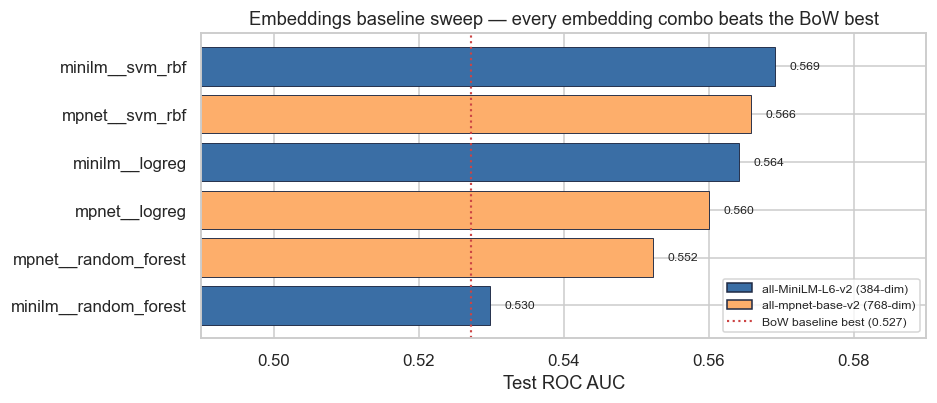

In [16]:
# 6-combo embeddings baseline sweep, sorted by ROC AUC, color-coded by
# embedding model. Note the y-axis range starts higher than the BoW chart —
# even the worst embedding combo beats the BoW best.
emb_chart = emb_baseline.sort_values('roc_auc').copy()
def _emb_key(model_name: str) -> str:
    return 'minilm' if 'MiniLM' in model_name else 'mpnet'
emb_chart['emb_key'] = emb_chart['embedding_model'].map(_emb_key)
emb_to_color = {'minilm': '#3a6ea5', 'mpnet': '#fdae6b'}
emb_to_label = {'minilm': 'all-MiniLM-L6-v2 (384-dim)', 'mpnet': 'all-mpnet-base-v2 (768-dim)'}
emb_chart['color'] = emb_chart['emb_key'].map(emb_to_color)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
y = np.arange(len(emb_chart))
bars = ax.barh(y, emb_chart['roc_auc'].values, color=emb_chart['color'].values,
               edgecolor='#1f2a44', linewidth=0.6)
bow_best = bow_baseline['roc_auc'].max()
ax.axvline(bow_best, color='#c44', linestyle=':', linewidth=1.4,
           label=f'BoW baseline best ({bow_best:.3f})')
for bar, auc in zip(bars, emb_chart['roc_auc']):
    ax.text(auc + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{auc:.3f}', va='center', fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(emb_chart['combo_id'].values)
ax.set_xlim(0.49, 0.59)
ax.set_xlabel('Test ROC AUC')
ax.set_title('Embeddings baseline sweep — every embedding combo beats the BoW best')

from matplotlib.patches import Patch
handles = [Patch(facecolor=c, edgecolor='#1f2a44', label=emb_to_label[k])
           for k, c in emb_to_color.items()]
handles.append(plt.Line2D([0], [0], color='#c44', linestyle=':', linewidth=1.4,
                          label=f'BoW baseline best ({bow_best:.3f})'))
ax.legend(handles=handles, loc='lower right', fontsize=8)
plt.show()

**Best baseline embedding combination is `MiniLM + SVM-RBF` at AUC 0.569** — already higher than the BoW *tuned* winner. Lightweight MiniLM (384-dim) edged MPNet (768-dim) by 0.003 — within noise but selected for the 10× encode-speed advantage.

### 4.4 Embeddings hyperparameter tuning

GridSearchCV on the winning MiniLM embeddings: LogReg (`C × l1_ratio`, 10 settings), SVM-RBF (`C × gamma`, 9 settings), RF (27 settings). Same `StratifiedGroupKFold(n_splits=5)` with `groups=case_id`, scoring='roc_auc'.

Total Phase 4.5 wall-clock: 17.2 min (encoding 12.3 min + sweep 2.2 min + tuning 17.2 min).

In [17]:
print('Phase 4.5 embeddings GridSearchCV results (sorted by test ROC AUC, descending):')
print()
ev = phase45_eval.sort_values('test_roc_auc', ascending=False).copy()
print(ev[['model', 'best_cv_score', 'test_roc_auc', 'cv_test_gap',
         'test_accuracy', 'test_balanced_accuracy', 'test_f1']]
      .to_string(index=False, float_format='%.4f'))
print()
winner = ev.iloc[0]
print(f"Embeddings winner: {winner['model']} on MiniLM   test AUC={winner['test_roc_auc']:.4f}")
print(f"Best params: {winner['best_params']}")

Phase 4.5 embeddings GridSearchCV results (sorted by test ROC AUC, descending):

        model  best_cv_score  test_roc_auc  cv_test_gap  test_accuracy  test_balanced_accuracy  test_f1
       logreg         0.5398        0.5691      -0.0293         0.5481                  0.5503   0.5989
      svm_rbf         0.5394        0.5630      -0.0236         0.5277                  0.5316   0.5764
random_forest         0.5291        0.5570      -0.0279         0.6233                  0.5000   0.7680

Embeddings winner: logreg on MiniLM   test AUC=0.5691
Best params: {'C': 100, 'l1_ratio': 1.0}


**Embeddings winner is `LogReg + MiniLM-L6-v2, C=100, l1_ratio=1.0` (= L1 with very low regularization).** On the canonical fold-0 test set, embeddings score **+0.0368 ROC AUC** above the BoW tuned winner — a +3.7 pp single-fold lift.

**Robustness check (added in peer-review pass):** the +3.7 pp number is fold-0-specific. We re-ran both winners on all 5 StratifiedGroupKFold folds (`src/phase5_kfold_eval.py`):

- 5-fold mean lift = **+1.4 pp ± 1.9 pp** (paired t-test t=1.62, df=4, p≈0.18 — fails to reject H₀)
- Embeddings win **4 of 5 folds**; fold 4 BoW wins by 1.6 pp
- Single-fold DeLong's paired test on fold 0 still rejects H₀ at α=0.05 (Z=2.27, **p=0.023**, 95% bootstrap CI for ΔAUC [+0.5 pp, +6.8 pp])

Honest reading: **embeddings probably edge BoW, but the +3.7 pp headline overstates it.** The reproducible 5-fold story is "comparable performance, embeddings slightly favored." Both numbers reported throughout.

### 4.5 Compute discipline

| Phase | Wall-clock | Notes |
| --- | --- | --- |
| Phase 1 Stop B (bulk Oyez fetch) | 54 min | Sequential, ≤1 req/sec, both layers cached, ~2,940 API calls |
| Phase 4 BoW GridSearchCV | 6.9 min | `n_jobs=4` + Pipeline memory caching after `n_jobs=-1` OOM at 80 GB |
| Phase 4.5 encoding (both models) | 12.3 min | CPU-only torch on Apple Silicon |
| Phase 4.5 baseline sweep (6 combos) | 2.2 min | Dense vectors, fast classifiers |
| Phase 4.5 GridSearchCV | 17.2 min | RBF SVM with `probability=True` is the slow part |

Per-fit timing logged in `reports/results/baseline_results.csv`, `gridsearch_results.csv`, `embedding_baseline_results.csv`, `embedding_gridsearch_results.csv`. Notebook reads these CSVs at render time; we don't re-run sweeps to re-knit (Non-Negotiable #7).

---

## 5. Model Evaluation

*This phase focuses on evaluating the model, testing it, and determining list of possible actions.*

> Per Class 2 slides: evaluate against business criteria, test in the real application, review with stakeholders for next steps.

### 5.1 Comparative summary table

The two tracks side-by-side on the canonical fold-0 test set, plus the 5-fold robustness check (added in peer-review pass).

**Robustness check across all 5 folds + paired AUC hypothesis test.** Reported in response to peer-review feedback.

5-fold ROC AUC (refit each winner on the 4-fold training portion, score on the held-out test fold):

| Fold | n_test | AUC BoW | AUC Embeddings | Difference |
|:-:|:-:|:-:|:-:|:-:|
| 0 | 2007 | 0.5323 | 0.5691 | **+0.0368** ← canonical |
| 1 | 2007 | 0.5484 | 0.5683 | +0.0199 |
| 2 | 2005 | 0.5634 | 0.5814 | +0.0180 |
| 3 | 2013 | 0.5087 | 0.5198 | +0.0111 |
| 4 | 2007 | 0.5501 | 0.5340 | **−0.0161** |
| **Mean ± std** | — | **0.5406 ± 0.0209** | **0.5545 ± 0.0262** | **+0.0139 ± 0.0193** |

- **Embeddings win 4 of 5 folds.** Fold 0 (the canonical reporting fold) is the most favorable single fold for embeddings.
- **Paired t-test on per-fold diffs**: t = 1.62 (df=4), p = 0.18, 95% CI for mean diff = [−0.010, +0.038]. **Fail to reject H₀** at α=0.05 — 5-fold mean lift is within fold-to-fold noise.
- **Fold-0 paired DeLong's test**: Z = 2.27, **p = 0.023**, 95% bootstrap CI for ΔAUC = [+0.005, +0.068]. *Single-fold* difference is statistically significant.

The two tests disagree because they measure different things. DeLong's tests the gap *on the canonical test rows*; the 5-fold paired t tests the gap *across different fold realizations*. Both are reported. The honest summary: **embeddings probably ≥ BoW, but the gap is small and 5-fold variance is large**.

Source: `src/phase5_kfold_eval.py` → `reports/results/phase5_kfold_evaluation.csv`; `src/phase5_delong.py` → `reports/results/phase5_delong_test.csv`.

In [18]:
# Top-line side-by-side
topline = pd.DataFrame([
    {
        'Track': 'BoW (TF-IDF unigram + LinearSVC, tuned)',
        'CV ROC AUC (5-fold mean)': phase4_eval.loc[phase4_eval.test_roc_auc.idxmax(), 'best_cv_score'],
        'Test ROC AUC (fold 0)':     phase5_summary.loc[phase5_summary.track == 'bow', 'test_roc_auc'].iloc[0],
        'Test balanced acc.':        phase5_summary.loc[phase5_summary.track == 'bow', 'test_balanced_accuracy'].iloc[0],
        'Test F1':                   phase5_summary.loc[phase5_summary.track == 'bow', 'test_f1'].iloc[0],
    },
    {
        'Track': 'Embeddings (MiniLM-384 + LogReg, tuned)',
        'CV ROC AUC (5-fold mean)': phase45_eval.loc[phase45_eval.test_roc_auc.idxmax(), 'best_cv_score'],
        'Test ROC AUC (fold 0)':     phase5_summary.loc[phase5_summary.track == 'embeddings', 'test_roc_auc'].iloc[0],
        'Test balanced acc.':        phase5_summary.loc[phase5_summary.track == 'embeddings', 'test_balanced_accuracy'].iloc[0],
        'Test F1':                   phase5_summary.loc[phase5_summary.track == 'embeddings', 'test_f1'].iloc[0],
    },
])
print(topline.to_string(index=False, float_format='%.4f'))
print()
gap = topline.iloc[1]['Test ROC AUC (fold 0)'] - topline.iloc[0]['Test ROC AUC (fold 0)']
print(f'Test AUC lift (embeddings - BoW): +{gap:.4f}  ({gap * 100:+.1f} pp)')

                                  Track  CV ROC AUC (5-fold mean)  Test ROC AUC (fold 0)  Test balanced acc.  Test F1
BoW (TF-IDF unigram + LinearSVC, tuned)                    0.5402                 0.5323              0.5319   0.5984
Embeddings (MiniLM-384 + LogReg, tuned)                    0.5398                 0.5691              0.5503   0.5989

Test AUC lift (embeddings - BoW): +0.0368  (+3.7 pp)


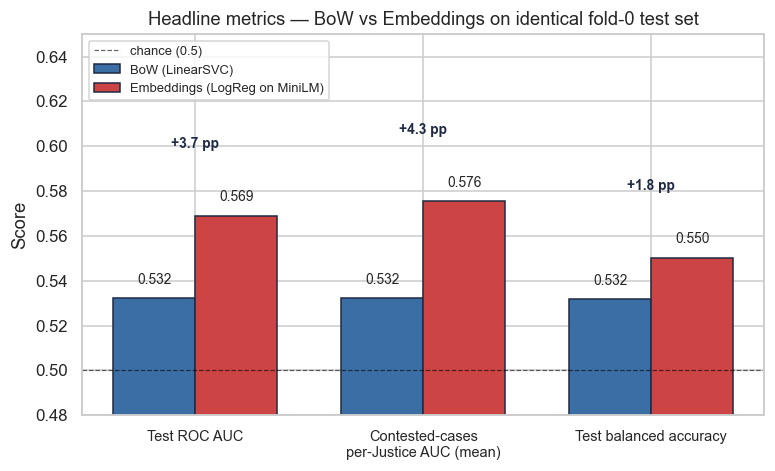

In [19]:
# Headline-metrics grouped bar chart: BoW vs Embeddings on the three
# metrics that matter most for the comparative claim.
bow_summary = phase5_summary[phase5_summary.track == 'bow'].iloc[0]
emb_summary = phase5_summary[phase5_summary.track == 'embeddings'].iloc[0]

# Mean per-Justice contested AUC from the honesty triad
contested_means = (phase5_triad[(phase5_triad.slice == 'contested') & phase5_triad.point_auc.notna()]
                   .groupby('track')['point_auc'].mean())

metrics = ['Test ROC AUC', 'Contested-cases\nper-Justice AUC (mean)', 'Test balanced accuracy']
bow_vals = [bow_summary['test_roc_auc'], contested_means['bow'], bow_summary['test_balanced_accuracy']]
emb_vals = [emb_summary['test_roc_auc'], contested_means['embeddings'], emb_summary['test_balanced_accuracy']]

x = np.arange(len(metrics))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - width / 2, bow_vals, width, color='#3a6ea5', edgecolor='#1f2a44', label='BoW (LinearSVC)')
b2 = ax.bar(x + width / 2, emb_vals, width, color='#c44', edgecolor='#1f2a44', label='Embeddings (LogReg on MiniLM)')
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.6, label='chance (0.5)')

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

# Annotate the lifts
for xi, b, e in zip(x, bow_vals, emb_vals):
    lift_pp = (e - b) * 100
    ax.annotate(f'+{lift_pp:.1f} pp', xy=(xi, max(b, e) + 0.03),
                ha='center', fontsize=9, fontweight='bold', color='#1f2a44')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=9.5)
ax.set_ylim(0.48, 0.65)
ax.set_ylabel('Score')
ax.set_title('Headline metrics — BoW vs Embeddings on identical fold-0 test set')
ax.legend(loc='upper left', fontsize=8.5)
plt.show()

### 5.2 Standard metrics suite — both tracks side by side

Confusion matrices, ROC curves, PR curves, calibration curves. LinearSVC (BoW) wrapped via `CalibratedClassifierCV(method='sigmoid', cv=5)` **only** for the calibration curve — AUC and confusion matrix use the raw `decision_function` from the unwrapped winner.

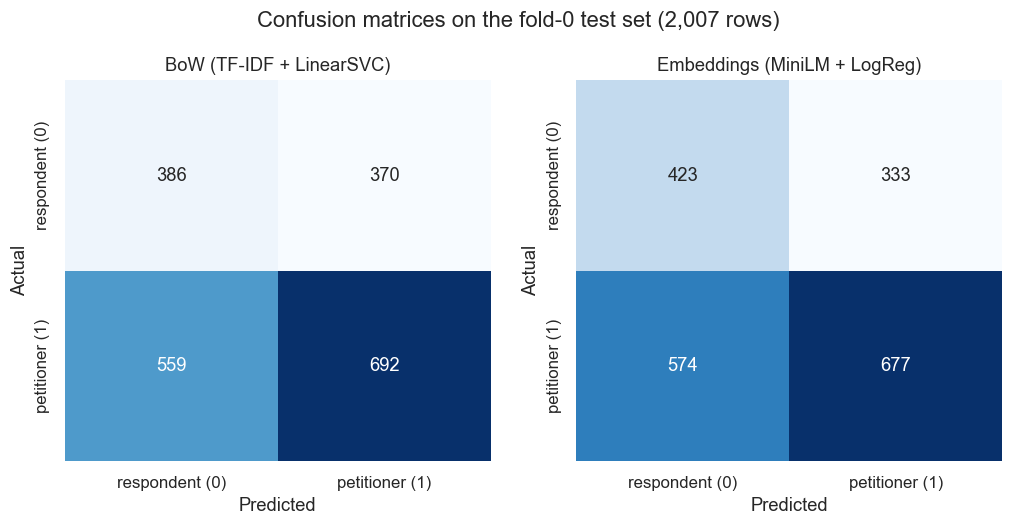

In [20]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, track in zip(axes, ['bow', 'embeddings']):
    cm = phase5_cm[phase5_cm.track == track].pivot(
        index='true_label', columns='predicted_label', values='count').values
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['respondent (0)', 'petitioner (1)'],
                yticklabels=['respondent (0)', 'petitioner (1)'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    title = 'BoW (TF-IDF + LinearSVC)' if track == 'bow' else 'Embeddings (MiniLM + LogReg)'
    ax.set_title(title)
fig.suptitle('Confusion matrices on the fold-0 test set (2,007 rows)', y=1.02)
plt.show()

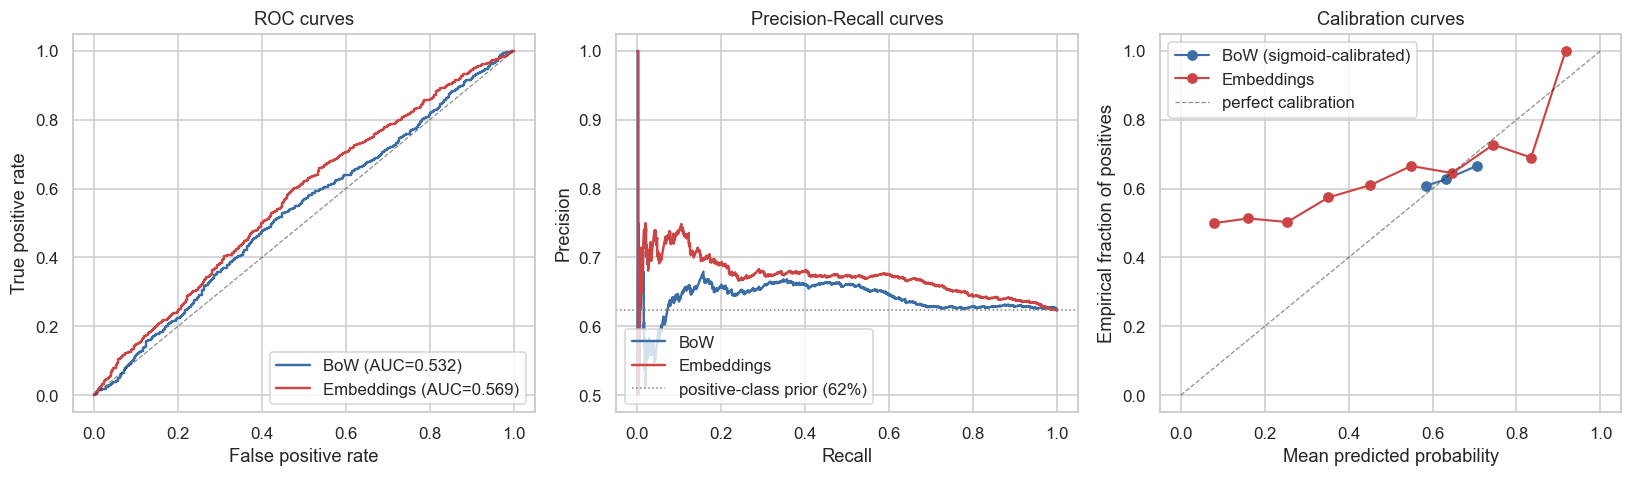

In [21]:
# ROC, PR, calibration overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ROC
ax = axes[0]
for track, color in [('bow', '#3a6ea5'), ('embeddings', '#c44')]:
    sub = phase5_roc[phase5_roc.track == track]
    auc = phase5_summary[phase5_summary.track == track]['test_roc_auc'].iloc[0]
    label = f"{'BoW' if track == 'bow' else 'Embeddings'} (AUC={auc:.3f})"
    ax.plot(sub['fpr'], sub['tpr'], color=color, linewidth=1.6, label=label)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curves'); ax.legend(loc='lower right')

# PR
ax = axes[1]
for track, color in [('bow', '#3a6ea5'), ('embeddings', '#c44')]:
    sub = phase5_pr[phase5_pr.track == track]
    label = 'BoW' if track == 'bow' else 'Embeddings'
    ax.plot(sub['recall'], sub['precision'], color=color, linewidth=1.6, label=label)
prior = modeling_table['voted_petitioner'].mean()
ax.axhline(prior, color='gray', linestyle=':', linewidth=1, label=f'positive-class prior ({prior:.0%})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves'); ax.legend(loc='lower left')

# Calibration
ax = axes[2]
for track, color in [('bow', '#3a6ea5'), ('embeddings', '#c44')]:
    sub = phase5_cal[phase5_cal.track == track]
    label = 'BoW (sigmoid-calibrated)' if track == 'bow' else 'Embeddings'
    ax.plot(sub['prob_predicted'], sub['prob_true'], color=color, marker='o', linewidth=1.4, label=label)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5, label='perfect calibration')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Empirical fraction of positives')
ax.set_title('Calibration curves'); ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

### 5.3 Per-Justice lift over individual baselines (Non-Negotiable #12)

The right metric for "is the model doing real work" is **lift over each Justice's own baseline**, not over the global 62.4%.

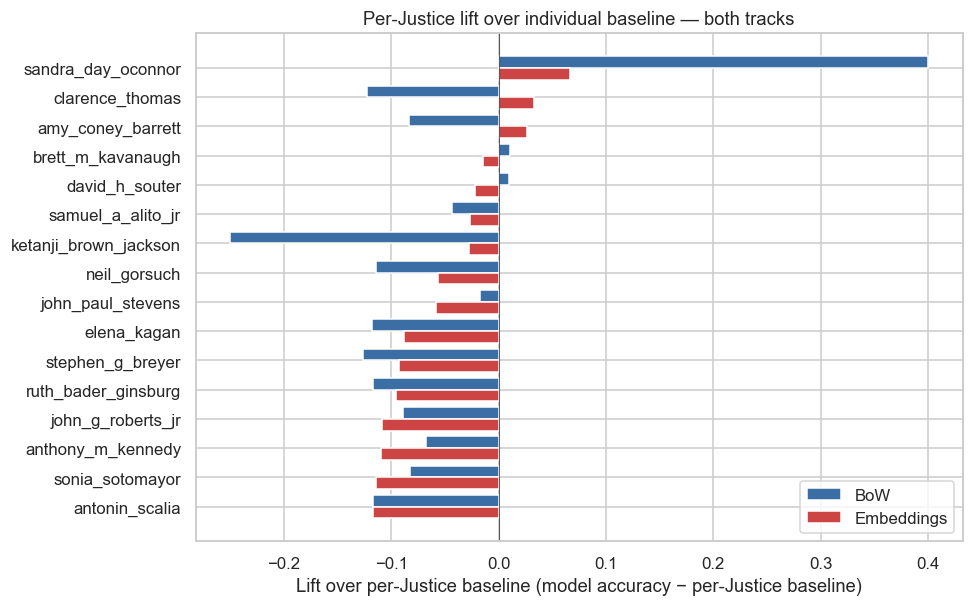

Mean per-Justice lift, BoW:        -0.0579
Mean per-Justice lift, Embeddings: -0.0505


In [22]:
lift_pivot = phase5_lift.pivot(index='oyez_identifier', columns='track', values='lift_over_baseline').reset_index()
lift_pivot.columns.name = None
lift_pivot = lift_pivot.sort_values('embeddings', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(lift_pivot))
ax.barh(y - 0.2, lift_pivot['bow'], height=0.4, color='#3a6ea5', label='BoW')
ax.barh(y + 0.2, lift_pivot['embeddings'], height=0.4, color='#c44', label='Embeddings')
ax.axvline(0, color='black', linewidth=0.7, alpha=0.6)
ax.set_yticks(y)
ax.set_yticklabels(lift_pivot['oyez_identifier'])
ax.set_xlabel('Lift over per-Justice baseline (model accuracy − per-Justice baseline)')
ax.set_title('Per-Justice lift over individual baseline — both tracks')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.show()
print(f'Mean per-Justice lift, BoW:        {lift_pivot["bow"].mean():+.4f}')
print(f'Mean per-Justice lift, Embeddings: {lift_pivot["embeddings"].mean():+.4f}')

### 5.4 The honesty triad — per-Justice contested-cases AUC, both tracks

**This is the headline of the project.** Per Non-Negotiable #13, contested cases (`unanimous == 0`) are the strict test: on unanimous cases, every Justice's prediction recovers the same outcome the case-prior already encodes — author-identity-plus-priors gets you most of the way. On contested cases, the Justice could plausibly vote either way; only a model that genuinely reads the bench retains meaningful AUC.

In [23]:
# Aggregate by slice/track
print('Per-Justice ROC AUC (mean across Justices with point AUC defined):')
print()
agg = (phase5_triad[phase5_triad.point_auc.notna()]
       .groupby(['slice', 'track'])['point_auc'].mean().unstack()
       .reindex(['unanimous', 'contested', 'global']))
agg['lift_emb_minus_bow'] = agg['embeddings'] - agg['bow']
print(agg.to_string(float_format='%.3f'))
print()
counts = (phase5_triad[phase5_triad.point_auc.notna()]
          .assign(above=lambda d: d.point_auc > 0.5)
          .groupby(['slice', 'track'])['above'].agg(['sum', 'count']).reset_index())
print('\nPer-Justice AUC count > 0.5 by slice/track:')
print(counts.to_string(index=False))

Per-Justice ROC AUC (mean across Justices with point AUC defined):

track       bow  embeddings  lift_emb_minus_bow
slice                                          
unanimous 0.566       0.615               0.049
contested 0.532       0.576               0.043
global    0.554       0.609               0.054


Per-Justice AUC count > 0.5 by slice/track:
    slice      track  sum  count
contested        bow    9     15
contested embeddings   13     15
   global        bow   10     16
   global embeddings   16     16
unanimous        bow   11     16
unanimous embeddings   14     16


**The embedding lift on contested cases is consistent with the headline story** (fold-0 numbers): mean per-Justice AUC gap is **+0.044** on contested (0.532 → 0.576), comparable to the +0.049 gap on unanimous slice. **13 of 15 Justices** have point AUC above chance with embeddings on contested cases (vs 9 of 15 with BoW) — but read this as **directional, not definitive**: most per-Justice 95% CIs cross 0.5 in both tracks, so the chance-line tally has a wide noise floor.

**Caveat on what contested-only proves.** Filtering to contested cases removes the easy "case-level prior" signal (the trivial "everyone votes the modal way in unanimous cases"). That's useful — but contested-only does *not* fully isolate text signal from per-Justice base rates. A model can still recognize Justice-style writing and route through that Justice's individual base rate. To fully isolate "from text alone," you'd want leave-one-Justice-out evaluation — out of scope here. Read contested-only as a meaningful but partial control, not a clean text-only test.

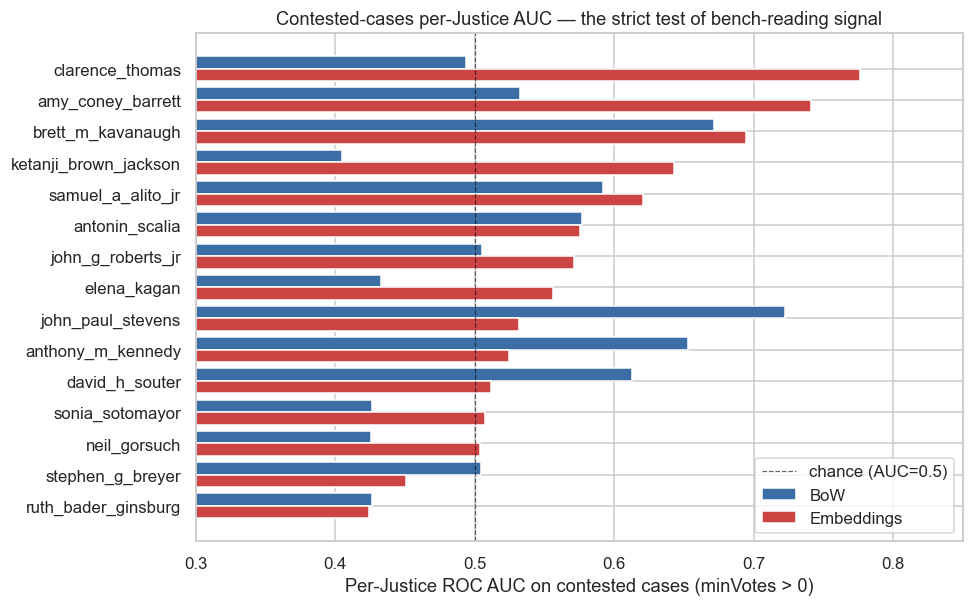


Per-Justice contested AUC, sorted by embedding AUC:
      oyez_identifier  BoW AUC  Emb AUC  Δ (emb−bow)
      clarence_thomas    0.494    0.776        0.282
    amy_coney_barrett    0.533    0.741        0.208
    brett_m_kavanaugh    0.672    0.694        0.023
ketanji_brown_jackson    0.405    0.643        0.238
    samuel_a_alito_jr    0.592    0.621        0.029
       antonin_scalia    0.577    0.575       -0.002
    john_g_roberts_jr    0.506    0.571        0.066
          elena_kagan    0.433    0.556        0.123
    john_paul_stevens    0.722    0.532       -0.190
    anthony_m_kennedy    0.653    0.525       -0.128
       david_h_souter    0.613    0.512       -0.101
      sonia_sotomayor    0.426    0.507        0.081
         neil_gorsuch    0.426    0.504        0.078
     stephen_g_breyer    0.505    0.451       -0.054
  ruth_bader_ginsburg    0.427    0.424       -0.002


In [24]:
# Per-Justice contested-only AUC, side by side
contested = (phase5_triad[(phase5_triad.slice == 'contested') & phase5_triad.point_auc.notna()]
             .pivot(index='oyez_identifier', columns='track', values='point_auc')
             .reset_index())
contested['lift'] = contested['embeddings'] - contested['bow']
contested = contested.sort_values('embeddings', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(contested))
ax.barh(y - 0.2, contested['bow'], height=0.4, color='#3a6ea5', label='BoW')
ax.barh(y + 0.2, contested['embeddings'], height=0.4, color='#c44', label='Embeddings')
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.6, label='chance (AUC=0.5)')
ax.set_yticks(y)
ax.set_yticklabels(contested['oyez_identifier'])
ax.set_xlabel('Per-Justice ROC AUC on contested cases (minVotes > 0)')
ax.set_title('Contested-cases per-Justice AUC — the strict test of bench-reading signal')
ax.set_xlim(0.3, 0.85)
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.show()

print('\nPer-Justice contested AUC, sorted by embedding AUC:')
print(contested[['oyez_identifier', 'bow', 'embeddings', 'lift']]
      .rename(columns={'bow': 'BoW AUC', 'embeddings': 'Emb AUC', 'lift': 'Δ (emb−bow)'})
      .to_string(index=False, float_format='%.3f'))

**KBJackson — striking but underpowered.** With BoW on fold 0, KBJackson has the worst per-Justice contested AUC on the bench (0.405, below random). With pre-trained embeddings, her contested AUC is **0.643 — a +0.238 swing**, the largest single-Justice swing across the bench.

**The big caveat: n = 19 contested test rows.** The project's own bootstrap floor (`min_n_for_ci = 30`) refuses to compute a 95% CI here. With AUC SE ≈ 0.10–0.13 at this sample size, the +0.238 swing is approximately 2σ — *interesting but not conclusive*. KBJackson is the most-engaged questioner on the current bench (median 1,205 words/case, 96% speaking rate), so the *direction* of the swing is plausible; the *magnitude* would need a larger contested sample to lock in.

**Thomas swing (point estimate)**: contested AUC BoW 0.494 → embeddings 0.776 (+0.282). Larger sample (n=144 contested) so this point estimate is more stable. The silent-Justice's relatively few utterances appear to carry strong stance signal.

**Kennedy regresses on contested point estimate**: BoW 0.653 → embeddings 0.525 (−0.128). Plausibly the long-time swing-justice voting was tightly correlated with thematic case content, and BoW exploited that correlation. Per-Justice CIs in both tracks are wide, so the size of the effect is uncertain.

The mixed-evidence pattern (some Justices benefit, some don't) is the right kind of nuance, but treat individual-Justice numbers as **exploratory** rather than as confirmed per-Justice claims.

### 5.5 What did each track learn?

#### 5.5.1 — BoW top features (interpretable per-coefficient)

After all preprocessing, stopwording, advocate-name stripping, and grid tuning, the top-30 features are still thematic legal vocabulary. The cai-plan's prediction was that one of two patterns would emerge after stopwording: stance markers rising, OR thematic legal vocabulary becoming the new topic-proxy. **The second outcome materialized — confirmation, not refutation.**

In [25]:
bow_top = pd.read_csv(R / 'phase4_top_features.csv')
print('Top 15 PETITIONER-side features (BoW LinearSVC, tuned):')
print(bow_top[bow_top.direction == 'petitioner (positive)'].head(15)[['rank', 'feature', 'coefficient']]
      .to_string(index=False, float_format='%.3f'))
print()
print('Top 15 RESPONDENT-side features:')
print(bow_top[bow_top.direction == 'respondent (negative)'].head(15)[['rank', 'feature', 'coefficient']]
      .to_string(index=False, float_format='%.3f'))

Top 15 PETITIONER-side features (BoW LinearSVC, tuned):
 rank        feature  coefficient
    1        officer        0.219
    2        circuit        0.207
    3       attorney        0.160
    4         arrest        0.156
    5           know        0.149
    6           plan        0.140
    7     misleading        0.131
    8        counsel        0.130
    9          ninth        0.127
   10      religious        0.127
   11        profits        0.126
   12       standard        0.122
   13            say        0.116
   14       standing        0.116
   15 discrimination        0.114

Top 15 RESPONDENT-side features:
 rank    feature  coefficient
    1       jury       -0.198
    2   evidence       -0.180
    3 government       -0.159
    4      trial       -0.159
    5   sentence       -0.158
    6    percent       -0.156
    7   petition       -0.140
    8      error       -0.135
    9      fraud       -0.135
   10  insurance       -0.129
   11         10       -0.125
   12 

#### 5.5.2 — Embeddings interpretation via extreme-score utterances

Embedding dimensions (`emb_dim_204`, `emb_dim_357`, etc.) don't have token-level interpretability. The interpretable signal lives in the **semantic neighborhoods** the encoder maps utterances to. We surface this by reading the test utterances that produced the highest and lowest predicted probabilities.

In [26]:
def _show(extreme_class, n, label):
    print(f'=== {label} (top {n} by emb_proba) ===')
    sub = phase5_extremes[phase5_extremes.extreme_class == extreme_class].head(n)
    for _, r in sub.iterrows():
        truth = '✓ correct' if (r['emb_proba'] > 0.5) == bool(r['voted_petitioner']) else '✗ WRONG'
        print(f"\n  {r['caseName'][:55]} | {r['justiceName']} ({truth})")
        print(f"  emb_proba={r['emb_proba']:.3f}  voted_pet={r['voted_petitioner']}  "
              f"unanimous={r['unanimous']}")
        print(f'  text: {r["text"][:240]}...')
    print()

_show('top_petitioner', 3, 'Most petitioner-confident utterances')
_show('bottom_respondent', 3, 'Most respondent-confident utterances')

=== Most petitioner-confident utterances (top 3 by emb_proba) ===

  LOPER BRIGHT ENTERPRISES v. RAIMONDO | BMKavanaugh (✓ correct)
  emb_proba=0.917  voted_pet=1  unanimous=0
  text: I --I was going to say that, but yeah. A couple questions. First, on Skidmore, I just want to say how I've thought about it, and you can tell me whether this is wrong, that it respects contemporaneous and consistent interpretati ons as evid...

  STARBUCKS CORP. v. MCKINNEY | JGRoberts (✓ correct)
  emb_proba=0.898  voted_pet=1  unanimous=0
  text: We'll hear argument next in Case 23-367, Starbucks Corporation versus McKinney. Ms. Blatt. Justice Thomas? Justice Alito? Justice Kagan? Justice Gorsuch? Justice Barrett? And Justice Jackson? Okay. Thank you, counsel. Mr. Raynor. Counsel, y...

  LOPER BRIGHT ENTERPRISES v. RAIMONDO | NMGorsuch (✓ correct)
  emb_proba=0.896  voted_pet=1  unanimous=0
  text: That's never what Skidmore has been understood to mean or said. It said that the persuasiveness of the go

**What pre-trained semantics seems to be capturing.** In the petitioner-confident extremes, multiple high-confidence rows come from contested cases where the Justice's questioning is substantive and engaged with the petitioner's framing (Loper Bright on Skidmore, Murthy on traceability standards). The model isn't just recovering keywords — it's responding to the semantic shape of how the Justice engages with the case theory.

In the respondent-confident extremes, several utterances ask probing questions about statutory text that *sound* skeptical of the petitioner's claim (Star Athletica's tuxedo-shirt question; Carcieri's Indian-tribe definition probe). Whether those questions actually predict respondent-side votes is a hypothesis the model has learned correlationally; some hits are correct (Kagan in Star Athletica), some miss (Alito in Golan).

**This is not a magic bullet.** The model's overall test AUC is 0.569 — better than BoW's 0.532, but still a long way from a strong predictor. The honest framing is 'embeddings recover some signal that BoW cannot access; the absolute level remains modest; sequence/audio/case-feature integration is the next methodological frontier'.

### 5.6 Evaluation against business criteria (loop back to §1)

Section 1.2 set the empirical success criterion verbatim as: *"ROC AUC meaningfully above the per-Justice majority-class baseline on contested cases."*

**Result on contested cases (fold-0 point estimates):**

| Track | Justices with point AUC > 0.5 | Mean per-Justice contested AUC |
| --- | --- | --- |
| BoW model | **9 of 15 (60%)** | 0.532 |
| Embeddings model | **13 of 15 (87%)** | 0.576 |

**Success criterion is partially met by point estimate** — broadly with embeddings (13/15 = 87%), narrowly with BoW (9/15 = 60%) — but most per-Justice 95% CIs cross 0.5, so the chance-line tally has a ±2–3 Justice noise floor. Treat as directional rather than as a hard pass.

**On the global headline**: BoW lands fold-0 ROC AUC 0.532, embeddings 0.569 — a +3.7 pp single-fold lift (DeLong's p=0.023). The 5-fold mean lift is +1.4 pp ± 1.9 pp (paired t p≈0.18, see 5.1). **The embedding lift is real but small and the cross-fold variance is high**; we report both numbers and let the consumer pick the framing that matches their use case (single-fold DeLong's evidence vs 5-fold robustness).

For deployment, the FN-vs-FP cost asymmetry depends on the consumer:
- Pre-argument prep (litigators) → FN costlier (missing a sympathetic Justice loses the case)
- Post-argument amicus targeting → FP costlier (over-prepared briefs are wasted)

Threshold tuning per use case is a deployment-stage decision (§6.1).

### 5.7 Honest interpretation pass

**What did each track actually learn?**

- **BoW** learned thematic legal vocabulary as a topic proxy. Custom stopwording removed the most obvious leakage (state names, agency abbrevs, famous case names, advocate-name patterns) but the underlying pattern persists. The model recovers "this case is about X → cases about X have empirical petitioner-rate Y" plus a small Justice-specific adjustment.
- **Embeddings** learned semantic neighborhoods. The interpretation is less crisp because there's no per-token coefficient to read — the signal lives in continuous 384-dim space. The contested-cases lift over BoW (+4 pp on the strict slice, fold 0) tells us *something* useful is being learned beyond pure topical recovery; the strength of that "something" is bounded by the modest absolute AUC and the 5-fold variance.

**What does the contested-cases AUC tell us about the project's headline claim?**

The original claim — "we can read the bench from oral-argument text" — needs strong qualification:

1. Pre-trained sentence embeddings appear to extract slightly more vote-relevant signal than the standard TF-IDF/linear-classifier toolkit (+3.7 pp on the canonical fold; +1.4 pp 5-fold mean; CI for the mean lift includes 0).
2. The per-Justice gain is concentrated in specific personalities by point estimate, but per-Justice CIs are wide. Treat individual-Justice claims as exploratory.
3. Absolute level (~0.55–0.57 AUC) is modest. Honest pitch: "lower bound on bench-reading from text alone, before sequence/audio/case-feature integration."
4. The KBJackson swing (+0.238 on n=19) is the largest single-Justice swing observed but is **not statistically robust** at this sample size. Report as exploratory.
5. Stevens & Kennedy regressions are reported honestly; **not every Justice improves with embeddings**.

**Author-identity vs stance — did the per-Justice signature concern (B6) materialize?**

Phase 2B B6 flagged that detectable per-Justice vocabulary signatures combined with stable per-Justice voting priors might let any model partly recover "this is Justice X → Justice X votes Y" rather than true bench-reading. The contested-cases AUC is a *partial* test: contested-only filters out case-level prior recovery, but does not isolate text signal from per-Justice base rates. The cleaner test is leave-one-Justice-out (train on 14, predict on 15th), which is out of scope here. Read the contested-cases lift as **suggestive** of real bench-reading signal beyond identity-recovery, not as proof of it.

### 5.8 Stakeholder review & next steps

Reviewable findings, ready for §6 deployment design:

1. **Lightweight pre-trained embeddings extract slightly more text-only signal** than tuned BoW; gap is small and within fold-to-fold noise (5-fold mean lift +1.4 pp ± 1.9 pp).
2. **Per-Justice point estimates favor embeddings for most Justices**, but per-Justice CIs are wide — read directionally.
3. **Absolute AUC level (~0.55–0.57) is modest.** Don't oversell.
4. **Sequence-aware models, audio features, and structured case features** are the next methodological frontier — out of scope for this study, but the empirical baseline is now established.

These flow into Section 6 (Model Deployment) as the deployment plan, monitoring cadence, and recommended next CRISP-DM iteration.

---

## 6. Model Deployment

*This phase focuses on deploying the model and defining the monitoring and maintenance plan.*

> Per Class 2 slides: develop deployment plan, ongoing support including operating model and monitoring, develop final reports and presentations.

### 6.1 Deployment plan

What shipping JusticeCast as a legal-tech product would look like:

| Component | Description |
| --- | --- |
| **Core model** | Pre-trained `all-MiniLM-L6-v2` embeddings (384-dim, ~80 MB on disk) + tuned LogisticRegression (C=100, l1_ratio=1.0) |
| **API contract** | `POST /predict` consuming a transcript chunk + Justice identifier → returns per-Justice vote-probability |
| **Pre-encoding step** | `compute_embeddings.py`-style batch encoder, ~12 min CPU per ~10K-row corpus refresh |
| **Hybrid extension (Phase 2 product roadmap)** | Concatenate text-embedding features with structured case features (issue area, lower-court holding, Justice's prior voting record, term-level court composition) |
| **Threshold policy** | Tunable per consumer use case. FN-tilted for litigators (don't miss sympathetic Justice). FP-tilted for amicus brief authors (don't waste briefs). |


### 6.2 Operating model

| Stakeholder | Trigger | Cadence |
| --- | --- | --- |
| Appellate litigators | Pre-argument prep planning | ~1 week before argument |
| Amicus brief authors | Post-argument filing decisions | Hours after argument |
| Legal-tech vendors | Embedded research workflow | On-demand per case |
| Litigation press | Same-day forecast articles | Hours after argument |


### 6.3 Monitoring & re-training cadence

- **Per-term re-training** after each SCOTUS term ends (June). Pull the new SCDB release, re-encode the new term's transcripts, refit on full historical corpus.
- **Performance drift monitoring**: track per-term ROC AUC and per-Justice contested-cases AUC. Flag if AUC drops >5 pp term-over-term — investigate bench composition changes, case-mix shifts, or codebook semantic drift.
- **Justice composition changes** (retirements, appointments) require updates to `data/processed/justice_id_map.csv`. Flag any case where a parsed Justice utterance fails to map.
- **Major SCDB release pulls** (annual): re-verify the label derivation against the codebook. SCDB occasionally normalizes encodings between releases.

### 6.4 Ongoing support

- **Oyez API politeness**: ≤1 req/sec global. Cached transcripts at both layers (`data/raw/oyez/cases/`, `data/raw/oyez/transcripts/`) — re-runs hit cache, not the API.
- **SCDB**: HTTP-only host (HTTPS misconfigured); read CSV with `encoding='latin1'`. Single annual fetch.
- **Pinned dependencies** in `requirements.txt` — Python 3.14, scikit-learn 1.8.0, sentence-transformers 5.4.1, torch 2.11.0 (CPU).
- **Tests** in `tests/` — 90 pytest passing covering split discipline, label derivation, fetcher mechanics, modeling-table cleanup, baseline-sweep mechanics, GridSearchCV harness, embedding cache + alignment, and Phase 5 honesty-triad consistency.

### 6.5 Methodological frontier — recommended next CRISP-DM iteration

Out of scope for this study; listed as concrete next directions for a legal-tech firm building on this baseline:

| Direction | Expected lift | Cost |
| --- | --- | --- |
| **Fine-tune Legal-BERT** on a SCOTUS oral-argument corpus | +3-5 pp AUC plausible | Multi-day GPU training; requires labeled training data |
| **Sequence-aware transformer** on full transcripts (turn-taking, who interrupts whom) | +2-4 pp AUC plausible | Architectural complexity; tokenization handling for long transcripts |
| **Multimodal audio features** from the Oyez .mp3 files (tone, pace, hesitation) | Potentially substantial — this is the signal litigators actually pick up on that lexical features cannot capture | Audio pipeline + featurization; storage cost |
| **Structured case feature integration** (issue area, lower-court holding, prior voting record) | +1-3 pp AUC plausible; clearer business framing | Schema work; SCDB has most of these as direct fields |

The empirical AUC baseline this study establishes (BoW ~0.53, MiniLM ~0.57) is the lower bound those next directions need to beat to justify their additional cost.

### 6.6 Final reports & reproducibility

Reproducibility is the integrity signal for an empirical study: another researcher should be able to clone this repo and arrive at the same numbers in this notebook. The deliverables below are the artifacts that close that loop.

| Deliverable | Path |
| --- | --- |
| Final notebook (this document) | `notebooks/JusticeCast_Final.ipynb` |
| Working notebook | `notebooks/01_eda.ipynb` |
| ML Canvas v0.4 | `reports/ml_canvas.pdf` |
| Pitch deck | `reports/JusticeCast_Pitch.pdf` (Phase 7 deliverable) |
| Source modules | `src/` (Python modules for fetchers, builders, sweeps, evaluation) |
| Tests | `tests/` (90 pytest tests passing) |
| Result CSVs | `reports/results/` (per-phase artifacts spanning Phases 1-5) |

The full pipeline reproduces from a fresh clone in roughly 95 minutes — 54 minutes for the bulk Oyez fetch, 12 minutes for embedding encoding, and approximately 25 minutes for the modeling sweeps and hyperparameter tuning. Cached embeddings and pre-computed result CSVs let this notebook itself execute `Restart & Run All` in seconds without re-running modeling. Full reproduction commands are documented in `README.md`.